# 📑Tutorial-7: Distinguisher Attack on SM4 Software Implementation

**🎯SM4 Algorithm**

SM4 is China's block cipher standard, released by the State Cryptography Administration in 2012. The relevant standard is "GM/T 0002-2012 SM4 Block Cipher Algorithm".

Compared with the AES algorithm, the side-channel attack on SM4 is more complex and must be carried out round by round. After successfully attacking four consecutive round keys, the master key can be recovered.

In this tutorial, we use the ANOVA distinguisher to demonstrate the attack process on the SM4 algorithm.

In [1]:
import nuscar
import numpy as np

### View Trace File Information

In [ ]:
reader = nuscar.ReaderETS("../datasets/sm4_stm32.ets")
ctn = nuscar.ContainerETS(reader) # Here you can set the frame parameter to define the sample preprocessing function

In [3]:
ctn

Number of traces,Points per trace,meta information
200,25000,"['ciphertext', 'key', 'plaintext']"


In [4]:
ctn.viewmeta()

No.,ciphertext,key,plaintext
0,"[245, 31, 176, 206, 9, 125, 6, 16, 65, 115, 60, 201, 118, 156, 170, 246]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]","[191, 25, 42, 131, 156, 103, 235, 162, 60, 137, 5, 77, 151, 88, 235, 176]"
1,"[156, 238, 141, 249, 43, 61, 66, 143, 132, 85, 138, 4, 92, 183, 228, 214]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]","[223, 214, 182, 93, 174, 112, 82, 183, 217, 28, 202, 134, 41, 233, 73, 37]"
2,"[150, 85, 149, 59, 101, 112, 189, 243, 159, 137, 78, 122, 82, 39, 113, 147]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]","[37, 2, 105, 49, 76, 157, 149, 211, 6, 106, 123, 176, 188, 103, 87, 228]"
3,"[133, 205, 193, 234, 231, 86, 79, 18, 74, 103, 27, 222, 237, 94, 7, 117]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]","[108, 132, 144, 131, 138, 180, 240, 178, 63, 53, 150, 77, 165, 27, 188, 160]"
4,"[211, 191, 55, 118, 190, 76, 108, 108, 70, 211, 255, 214, 238, 61, 116, 222]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]","[177, 95, 249, 207, 30, 103, 129, 26, 143, 192, 206, 203, 215, 186, 75, 112]"


### Attacking Round 1

In [5]:
sf = nuscar.ciphers.sm4.attack_sbox_hw() 

In [ ]:
dist = nuscar.distinguisher.ANOVADistinguisher(partitions=range(9)) # Hamming weight model, classes 0-8

In [7]:
task = nuscar.task.DistinguisherTask(ctn, sf, distinguisher=dist)

In [8]:
task.run()

  0%|          | 0/200 [00:00<?, ?it/s]

2026-01-11 20:20:43,590 - nuscar.task - INFO - check selection func pass
2026-01-11 20:20:43,591 - nuscar.task - INFO - check memory pass
2026-01-11 20:20:43,591 - nuscar.task - INFO - task Dist Task: 200 traces, 1 distinguisher, batch_size=1000, nb_samples=25000
2026-01-11 20:20:51,496 - nuscar.task - INFO - Task completed, time taken: 7.9 seconds


In [9]:
task.show_candidate()

,0,1,2,3
rank 1,83,144,64,28
rank 2,170,113,125,111
rank 3,98,185,181,167


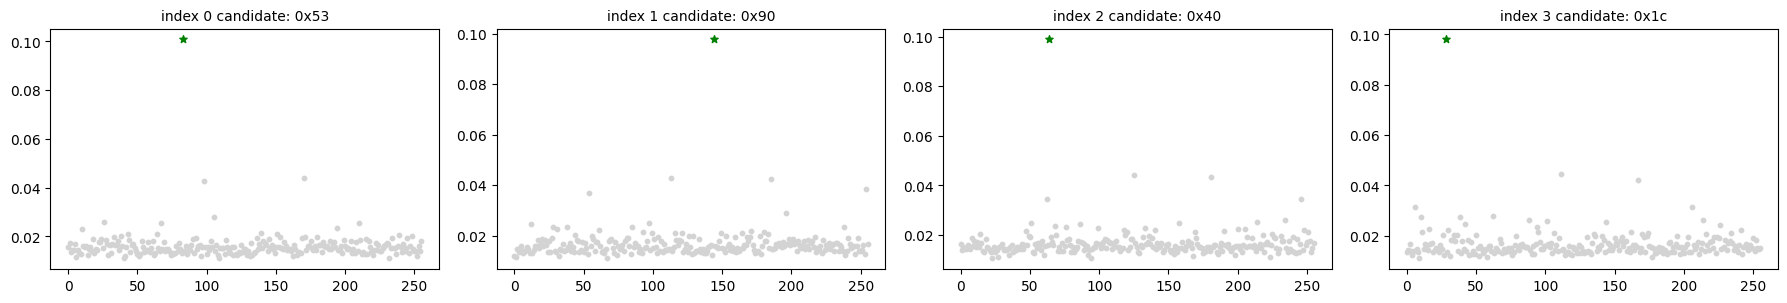

In [10]:
task.show_result()

Obtain the guessed round key of the first round, used to attack the second round

### Attacking Round 2

Based on the first-round guessed round key obtained in the previous step, compute the output value of the second round

In [11]:
rk = np.array([[83,	144, 64,28]], dtype=np.uint8)

In [12]:
sf = nuscar.ciphers.sm4.attack_sbox_hw(rk=rk)

In [ ]:
dist = nuscar.distinguisher.ANOVADistinguisher(partitions=range(9)) # Hamming weight model, classes 0-8

In [14]:
task = nuscar.task.DistinguisherTask(ctn, sf, distinguisher=dist)

In [15]:
task.run()

  0%|          | 0/200 [00:00<?, ?it/s]

2026-01-11 20:20:52,620 - nuscar.task - INFO - check selection func pass
2026-01-11 20:20:52,620 - nuscar.task - INFO - check memory pass
2026-01-11 20:20:52,621 - nuscar.task - INFO - task Dist Task: 200 traces, 1 distinguisher, batch_size=1000, nb_samples=25000
2026-01-11 20:20:57,943 - nuscar.task - INFO - Task completed, time taken: 5.3 seconds


In [16]:
task.show_candidate()

,0,1,2,3
rank 1,56,60,179,6
rank 2,42,32,236,163
rank 3,226,43,112,107


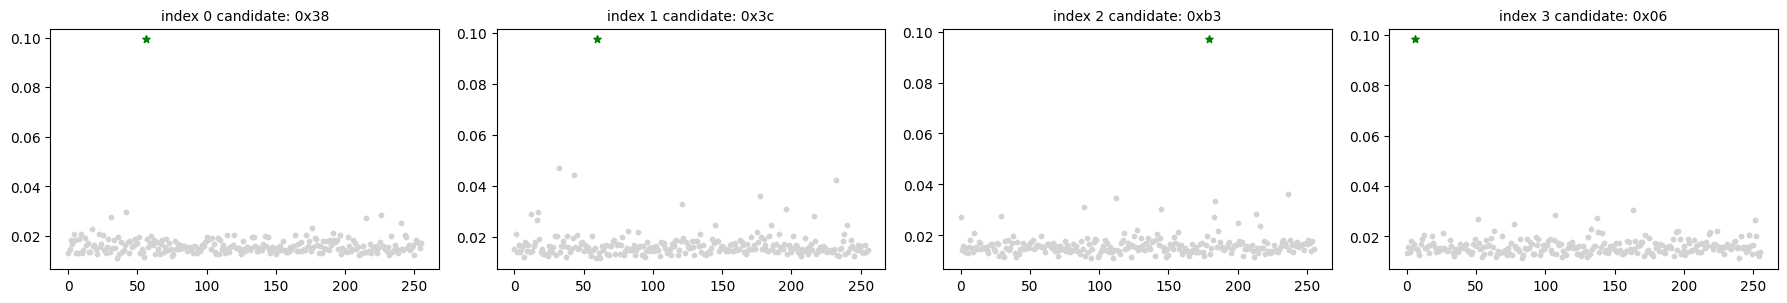

In [17]:
task.show_result()

Obtain the guessed round key of the second round, used for the next round of the attack

### Attacking Round 3

Using the guessed round keys of rounds 1 and 2 obtained in the previous 2 steps, compute the output value of round 3

In [18]:
rk = np.array([[83,	144, 64,28],[56, 60, 179,  6]], dtype=np.uint8)

In [19]:
sf = nuscar.ciphers.sm4.attack_sbox_hw(rk=rk)

In [20]:
dist = nuscar.distinguisher.ANOVADistinguisher(partitions=range(9)) # Hamming weight model, classes 0-8

In [21]:
task = nuscar.task.DistinguisherTask(ctn, sf, distinguisher=dist)

In [22]:
task.run()

  0%|          | 0/200 [00:00<?, ?it/s]

2026-01-11 20:20:58,709 - nuscar.task - INFO - check selection func pass
2026-01-11 20:20:58,710 - nuscar.task - INFO - check memory pass
2026-01-11 20:20:58,710 - nuscar.task - INFO - task Dist Task: 200 traces, 1 distinguisher, batch_size=1000, nb_samples=25000
2026-01-11 20:21:04,069 - nuscar.task - INFO - Task completed, time taken: 5.4 seconds


In [23]:
task.show_candidate()

,0,1,2,3
rank 1,115,237,102,77
rank 2,17,96,5,220
rank 3,217,168,205,20


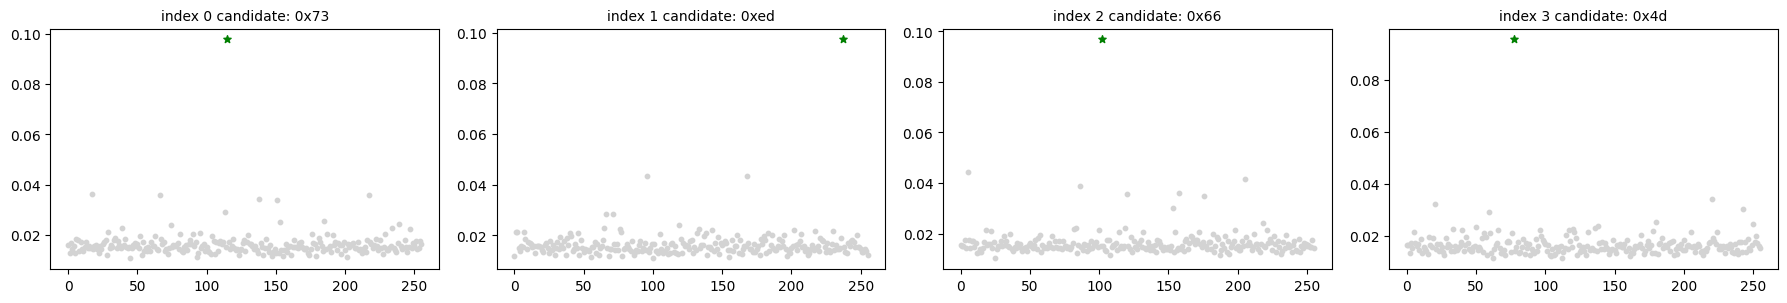

In [24]:
task.show_result()

Obtain the guessed round-3 round key, to be used for attacking the next round

## Attacking round 4

Using the guessed round keys of rounds 1, 2, and 3 obtained in the previous 3 steps, compute the output value of round 4

In [25]:
rk = np.array([[83,	144, 64,28],[56, 60, 179,  6], [115, 237, 102, 77]], dtype=np.uint8)

In [26]:
sf = nuscar.ciphers.sm4.attack_sbox_hw(rk=rk)

In [27]:
dist = nuscar.distinguisher.ANOVADistinguisher(partitions=range(9)) # Hamming weight model, classes 0-8

In [28]:
task = nuscar.task.DistinguisherTask(ctn, sf, distinguisher=dist)

In [29]:
task.run()

  0%|          | 0/200 [00:00<?, ?it/s]

2026-01-11 20:21:04,565 - nuscar.task - INFO - check selection func pass
2026-01-11 20:21:04,566 - nuscar.task - INFO - check memory pass
2026-01-11 20:21:04,566 - nuscar.task - INFO - task Dist Task: 200 traces, 1 distinguisher, batch_size=1000, nb_samples=25000
2026-01-11 20:21:10,661 - nuscar.task - INFO - Task completed, time taken: 6.1 seconds


In [30]:
task.show_candidate()

,0,1,2,3
rank 1,35,154,249,190
rank 2,249,56,46,98
rank 3,49,240,230,170


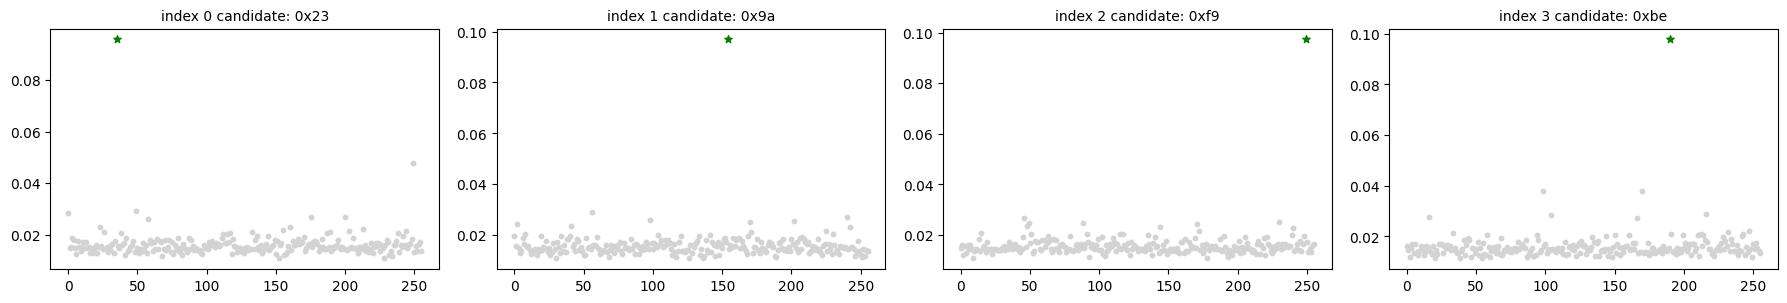

In [31]:
task.show_result()

Obtain the guessed round-4 round key

### Deriving the master key from the round keys

In [32]:
rk = np.array([[83,	144, 64,28],[56, 60, 179,  6], [115, 237, 102, 77], [35, 154, 249, 190]], dtype=np.uint8)

In [33]:
nuscar.ciphers.sm4.inv_key_schedule(rk)

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]],
      dtype=uint8)